## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv"
df = pd.read_csv(url)

df_tidy = df.drop(columns=['total_litres_of_pure_alcohol']).melt(
    id_vars=['country'], 
    var_name='drink', 
    value_name='servings'
)

## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

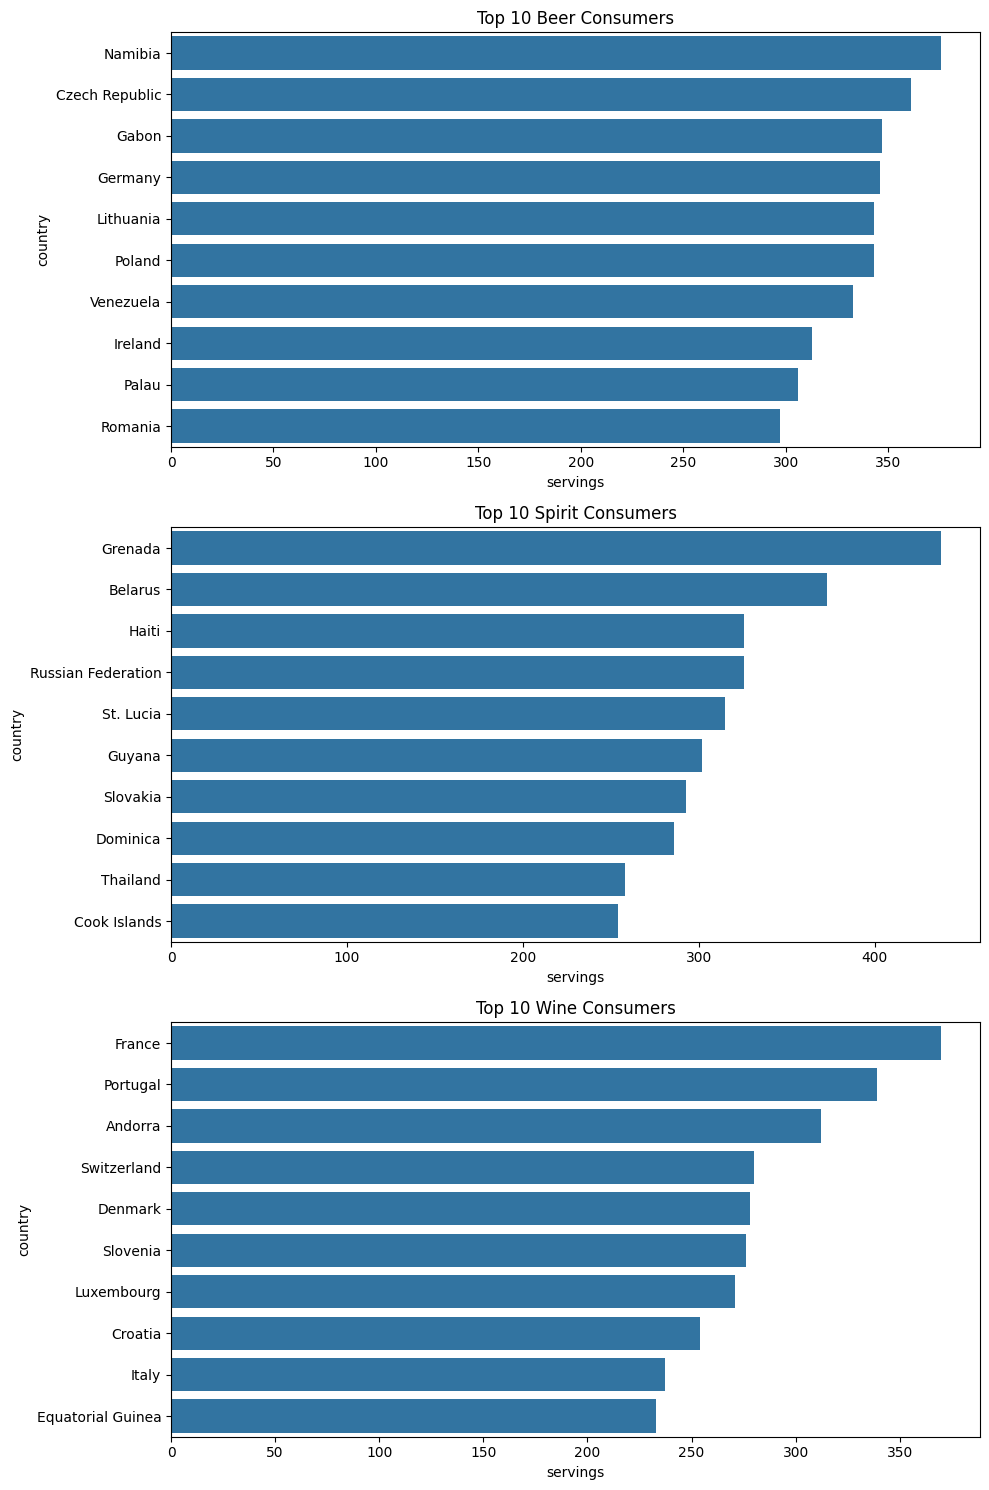

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_tidy['drink'] = df_tidy['drink'].str.replace('_servings', '')

top_beer = df_tidy[df_tidy['drink'] == 'beer'].nlargest(10, 'servings')
top_spirit = df_tidy[df_tidy['drink'] == 'spirit'].nlargest(10, 'servings')
top_wine = df_tidy[df_tidy['drink'] == 'wine'].nlargest(10, 'servings')

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

sns.barplot(data=top_beer, x='servings', y='country', ax=axes[0]).set(title='Top 10 Beer Consumers')
sns.barplot(data=top_spirit, x='servings', y='country', ax=axes[1]).set(title='Top 10 Spirit Consumers')
sns.barplot(data=top_wine, x='servings', y='country', ax=axes[2]).set(title='Top 10 Wine Consumers')

plt.tight_layout()
plt.show()



## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [3]:
df_wide = df_tidy.pivot_table(
    index='country', 
    columns='drink', 
    values='servings'
)

df_wide.head()

drink,beer,spirit,wine
country,,,
Afghanistan,0.0,0.0,0.0
Albania,89.0,132.0,54.0
Algeria,25.0,0.0,14.0
Andorra,245.0,138.0,312.0
Angola,217.0,57.0,45.0
